# Synthetic A1/A2/B/C Subtype Demo

This notebook builds the challenging subtype simulation directly in the notebook and runs MetaSort on the generated pseudobulks.

The intended failure mode is that A1 and A2 are globally similar and share a high-expression noisy block, while each has a smaller stable marker block. A useful weighting strategy should suppress shared noisy genes and improve A1/A2 separation.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CWD = Path.cwd().resolve()
candidates = [CWD, CWD.parent]
REPO_ROOT = next((path for path in candidates if (path / "metasort").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError("Please run this notebook from the MetaSort repository or its notebooks directory.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from metasort import MetaSortConfig, MetaSortSolver

RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)

print(f"Repo root: {REPO_ROOT}")

Repo root: /home/yunhao/WeightOptimizationDebug/metasort_jk


## Simulation Design

Gene blocks:

- `0:200`: shared housekeeping genes.
- `200:320`: A1/A2 shared high-expression noisy block. This block is intentionally large and weakly subtype-informative.
- `320:350`: stable A1 marker genes.
- `350:380`: stable A2 marker genes.
- `380:470`: B marker genes.
- `470:560`: C marker genes.
- `560:590`: weak A1 marker genes.
- `590:620`: weak A2 marker genes.

Each simulated single cell is column-normalized before pseudobulk sampling, so cell-level total UMI effects are removed before aggregation.

In [18]:
CELL_TYPES = ["A1", "A2", "B", "C"]
BLOCKS = {
    "housekeeping": (0, 200),
    "shared_noisy_A1_A2": (200, 320),
    "A1_marker": (320, 350),
    "A2_marker": (350, 380),
    "B_marker": (380, 470),
    "C_marker": (470, 560),
    "weak_A1_marker": (560, 590),
    "weak_A2_marker": (590, 620),
    "background": (620, 800),
}


def normalize_columns(matrix):
    matrix = np.asarray(matrix, dtype=float)
    col_sums = matrix.sum(axis=0, keepdims=True)
    col_sums[col_sums <= 0] = 1.0
    return matrix / col_sums


def normalize_vector(vector):
    vector = np.asarray(vector, dtype=float)
    total = float(vector.sum())
    if total <= 0:
        raise ValueError("Cannot normalize a zero-sum vector.")
    return vector / total


def build_reference_profiles(n_genes=800, cell_types=CELL_TYPES):
    genes = np.array([f"Gene{i:04d}" for i in range(n_genes)])
    profiles = {cell_type: np.full(n_genes, 0.02, dtype=float) for cell_type in cell_types}

    profiles["A1"][:200] += 0.25
    profiles["A2"][:200] += 0.25
    profiles["B"][:200] += 0.20
    profiles["C"][:200] += 0.18

    profiles["A1"][200:320] += 0.55
    profiles["A2"][200:320] += 0.53

    profiles["A1"][320:350] += 0.32
    profiles["A2"][350:380] += 0.32

    profiles["B"][380:470] += 0.40
    profiles["C"][470:560] += 0.38

    profiles["A1"][560:590] += 0.10
    profiles["A2"][590:620] += 0.10

    reference = np.column_stack([profiles[cell_type] for cell_type in cell_types])
    return genes, list(cell_types), normalize_columns(reference)


def generate_single_cells(reference, cell_types, cells_per_type=800, seed=0):
    rng = np.random.default_rng(seed)
    n_genes, n_types = reference.shape
    single_expr = np.zeros((n_genes, cells_per_type * n_types), dtype=float)
    labels = []
    col = 0

    shared_noisy = slice(*BLOCKS["shared_noisy_A1_A2"])
    marker_a1 = slice(*BLOCKS["A1_marker"])
    marker_a2 = slice(*BLOCKS["A2_marker"])

    for type_idx, cell_type in enumerate(cell_types):
        mean_profile = reference[:, type_idx]
        for _ in range(cells_per_type):
            profile = mean_profile * rng.lognormal(mean=0.0, sigma=0.35, size=n_genes)

            if cell_type in {"A1", "A2"}:
                profile[shared_noisy] *= rng.lognormal(
                    mean=0.0, sigma=0.90, size=shared_noisy.stop - shared_noisy.start
                )
                stable_slice = marker_a1 if cell_type == "A1" else marker_a2
                profile[stable_slice] *= rng.lognormal(
                    mean=0.0, sigma=0.08, size=stable_slice.stop - stable_slice.start
                )
                dropout_mask = rng.random(shared_noisy.stop - shared_noisy.start) < 0.18
                profile[shared_noisy][dropout_mask] *= 0.2

            counts = rng.poisson(np.clip(profile * 1200.0, 1e-8, None))
            if counts.sum() <= 0:
                counts[rng.integers(0, n_genes)] = 1
            single_expr[:, col] = counts
            labels.append(cell_type)
            col += 1

    return normalize_columns(single_expr), np.array(labels, dtype=object)


def counts_from_proportions(proportions, total_cells):
    raw = np.asarray(proportions, dtype=float) * int(total_cells)
    counts = np.floor(raw).astype(int)
    remainder = int(total_cells) - int(counts.sum())
    if remainder > 0:
        order = np.argsort(raw - counts)[::-1]
        counts[order[:remainder]] += 1
    return counts


def sample_pseudobulk(single_expr, labels, cell_types, proportions, total_cells, seed=0):
    rng = np.random.default_rng(seed)
    sampled_counts = counts_from_proportions(proportions, total_cells)
    selected = []
    for cell_type, n_cells in zip(cell_types, sampled_counts):
        candidates = np.flatnonzero(labels == cell_type)
        chosen = rng.choice(candidates, size=int(n_cells), replace=True)
        selected.extend(chosen.tolist())

    selected = np.array(selected, dtype=int)
    bulk = single_expr[:, selected].sum(axis=1)
    return normalize_vector(bulk), sampled_counts, sampled_counts / sampled_counts.sum()

In [19]:
genes, cell_types, signature = build_reference_profiles()
single_expr, labels = generate_single_cells(signature, cell_types, cells_per_type=800, seed=RANDOM_SEED)

print(signature.shape, single_expr.shape)
pd.Series(labels).value_counts().loc[cell_types]

(800, 4) (800, 3200)


A1    800
A2    800
B     800
C     800
Name: count, dtype: int64

## Run MetaSort

`truth` is defined as the actual sampled cell count ratio, not the template ratio. This avoids counting integer rounding as estimation error.

In [20]:
PROPORTION_TEMPLATES = np.array([
    [0.38, 0.34, 0.16, 0.12],
    [0.42, 0.30, 0.16, 0.12],
    [0.30, 0.40, 0.15, 0.15],
    [0.36, 0.36, 0.14, 0.14],
])
TOTAL_CELLS = 120

config = MetaSortConfig(
    convergence_tol=0.001,
    max_iter=100,
    lambda_hessian=1.0,
    lambda_avg_gradient=1.0,
    lambda_residual=1.5,
    lambda_gene_importance=0.0,
    lambda3=0.01,
    lambda4=0.001,
    avg_gradient_n_perturbations=20,
    avg_gradient_perturb_scale=0.02,
    print_info=False,
)
solver = MetaSortSolver(config)
weight_records = []


def l1_error(x, y):
    return float(np.sum(np.abs(np.asarray(x) - np.asarray(y))))


def run_metasort_with_weights(signature, bulk, cell_types):
    cfg = solver.config
    initial_solution = solver.solve_initial(signature, bulk)
    initial_proportions = solver._normalize_solution(initial_solution)

    solution = initial_solution.copy()
    meta_weights = np.ones(signature.shape[0], dtype=float)
    changes = []
    final_base = np.ones(signature.shape[0], dtype=float)
    final_meta = np.ones(signature.shape[0], dtype=float)
    final_metrics = {}
    converged = False

    for _ in range(cfg.max_iter):
        new_solution, meta_step, meta_metrics = solver.solve_meta_weighted_step(
            signature=signature,
            bulk=bulk,
            current_solution=solution,
            prev_meta_weights=meta_weights,
        )
        solution_average = (new_solution + cfg.averaging_old_weight * solution) / float(cfg.averaging_old_weight + 1)
        change = float(np.linalg.norm(solution_average - solution))
        changes.append(change)
        solution = solution_average
        meta_weights = meta_step
        final_meta = meta_step
        final_metrics = meta_metrics
        if change <= cfg.convergence_tol:
            converged = True
            break

    proportions = solver._normalize_solution(solution)
    total_weights = np.clip(final_base * final_meta, cfg.min_weight_floor, None)
    return {
        "initial_proportions": initial_proportions,
        "proportions": proportions,
        "iterations": len(changes),
        "converged": converged,
        "base_weights": final_base,
        "meta_weights": final_meta,
        "total_weights": total_weights,
        "meta_weight_metrics": final_metrics,
    }


def run_one_simulation(sim_id, template):
    bulk, sampled_counts, truth = sample_pseudobulk(
        single_expr=single_expr,
        labels=labels,
        cell_types=cell_types,
        proportions=template,
        total_cells=TOTAL_CELLS,
        seed=1000 + sim_id,
    )
    result = run_metasort_with_weights(signature, bulk, cell_types)

    initial = np.array(result["initial_proportions"], dtype=float)
    metasort = np.array(result["proportions"], dtype=float)
    total_weights = np.asarray(result["total_weights"], dtype=float)
    meta_weights = np.asarray(result["meta_weights"], dtype=float)
    base_weights = np.asarray(result["base_weights"], dtype=float)

    for gene_idx, gene in enumerate(genes):
        block_name = next(name for name, (start, end) in BLOCKS.items() if start <= gene_idx < end)
        weight_records.append({
            "Simulation": f"Sim{sim_id + 1}",
            "Gene": gene,
            "GeneIndex": gene_idx,
            "Block": block_name,
            "BaseWeight": base_weights[gene_idx],
            "MetaWeight": meta_weights[gene_idx],
            "TotalWeight": total_weights[gene_idx],
        })

    row = {
        "Simulation": f"Sim{sim_id + 1}",
        "TotalCells": int(sampled_counts.sum()),
        "SampledCounts": dict(zip(cell_types, sampled_counts.astype(int).tolist())),
        "Initial_L1": l1_error(initial, truth),
        "MetaSort_L1": l1_error(metasort, truth),
        "Initial_Accuracy": 1.0 - l1_error(initial, truth) / 2.0,
        "MetaSort_Accuracy": 1.0 - l1_error(metasort, truth) / 2.0,
        "Initial_A1A2_L1": l1_error(initial[:2], truth[:2]),
        "MetaSort_A1A2_L1": l1_error(metasort[:2], truth[:2]),
        "Iterations": result["iterations"],
        "Converged": result["converged"],
        "MetaWeightMin": float(np.min(meta_weights)),
        "MetaWeightMean": float(np.mean(meta_weights)),
        "MetaWeightMax": float(np.max(meta_weights)),
        "TotalWeightMin": float(np.min(total_weights)),
        "TotalWeightMean": float(np.mean(total_weights)),
        "TotalWeightMax": float(np.max(total_weights)),
    }
    for name, value in zip(cell_types, truth):
        row[f"Truth_{name}"] = value
    for name, value in zip(cell_types, initial):
        row[f"Initial_{name}"] = value
    for name, value in zip(cell_types, metasort):
        row[f"MetaSort_{name}"] = value
    if result["meta_weight_metrics"]:
        for key, value in result["meta_weight_metrics"].items():
            row[f"Loss_{key}"] = value
    return row

rows = [run_one_simulation(i, template) for i, template in enumerate(PROPORTION_TEMPLATES)]
summary_df = pd.DataFrame(rows)
weights_df = pd.DataFrame(weight_records)
summary_df

,Simulation,TotalCells,SampledCounts,Initial_L1,MetaSort_L1,Initial_Accuracy,MetaSort_Accuracy,Initial_A1A2_L1,MetaSort_A1A2_L1,Iterations,...,MetaSort_C,Loss_total_loss,Loss_hessian_loss,Loss_avg_gradient_loss,Loss_residual_penalty,Loss_gene_importance_loss,Loss_reg_loss,Loss_min_simplex_hessian_eig,Loss_mean_simplex_hessian_eig,Loss_max_simplex_hessian_eig
0,Sim1,120,"{'A1': 46, 'A2': 41, 'B': 19, 'C': 14}",0.135635,0.057902,0.932183,0.971049,0.067817,0.028951,11,...,0.104268,20.492584,20.216182,1.233330e-09,0.000035,-0.0,0.276367,0.000284,0.001715,0.002684
1,Sim2,120,"{'A1': 50, 'A2': 36, 'B': 19, 'C': 15}",0.126683,0.040509,0.936659,0.979745,0.063341,0.020255,12,...,0.114667,20.520726,20.232609,1.136937e-09,0.000023,-0.0,0.288093,0.000271,0.001751,0.002910
2,Sim3,120,"{'A1': 36, 'A2': 48, 'B': 18, 'C': 18}",0.135085,0.040098,0.932457,0.979951,0.067543,0.020049,12,...,0.137943,20.635195,20.347738,9.682445e-10,0.000024,-0.0,0.287433,0.000265,0.001673,0.002763
3,Sim4,120,"{'A1': 43, 'A2': 43, 'B': 17, 'C': 17}",0.130608,0.040539,0.934696,0.979730,0.065304,0.020270,12,...,0.130694,20.579928,20.292137,1.064829e-09,0.000025,-0.0,0.287765,0.000258,0.001737,0.002891


In [21]:
display_cols = [
    "Simulation", "Initial_L1", "MetaSort_L1", "Initial_A1A2_L1", "MetaSort_A1A2_L1",
    "Initial_Accuracy", "MetaSort_Accuracy", "Iterations", "Converged",
]
summary_df[display_cols].round(4)

,Simulation,Initial_L1,MetaSort_L1,Initial_A1A2_L1,MetaSort_A1A2_L1,Initial_Accuracy,MetaSort_Accuracy,Iterations,Converged
0,Sim1,0.1356,0.0579,0.0678,0.0290,0.9322,0.9710,11,True
1,Sim2,0.1267,0.0405,0.0633,0.0203,0.9367,0.9797,12,True
2,Sim3,0.1351,0.0401,0.0675,0.0200,0.9325,0.9800,12,True
3,Sim4,0.1306,0.0405,0.0653,0.0203,0.9347,0.9797,12,True


In [22]:
prop_cols = []
for prefix in ["Truth", "Initial", "MetaSort"]:
    prop_cols.extend([f"{prefix}_{cell_type}" for cell_type in cell_types])
summary_df[["Simulation"] + prop_cols].round(4)

,Simulation,Truth_A1,Truth_A2,Truth_B,Truth_C,Initial_A1,Initial_A2,Initial_B,Initial_C,MetaSort_A1,MetaSort_A2,MetaSort_B,MetaSort_C
0,Sim1,0.3833,0.3417,0.1583,0.1167,0.4231,0.3697,0.1215,0.0857,0.4007,0.3533,0.1418,0.1043
1,Sim2,0.4167,0.3000,0.1583,0.1250,0.4456,0.3344,0.1267,0.0933,0.4279,0.3090,0.1484,0.1147
2,Sim3,0.3000,0.4000,0.1500,0.1500,0.3430,0.4245,0.1175,0.1149,0.3082,0.4119,0.1420,0.1379
3,Sim4,0.3583,0.3583,0.1417,0.1417,0.3929,0.3891,0.1090,0.1090,0.3657,0.3713,0.1324,0.1307


In [23]:
out_path = REPO_ROOT / "synthetic_subtype_metasort_results.csv"
summary_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

Saved: /home/yunhao/WeightOptimizationDebug/metasort_jk/synthetic_subtype_metasort_results.csv


## Accuracy Plots

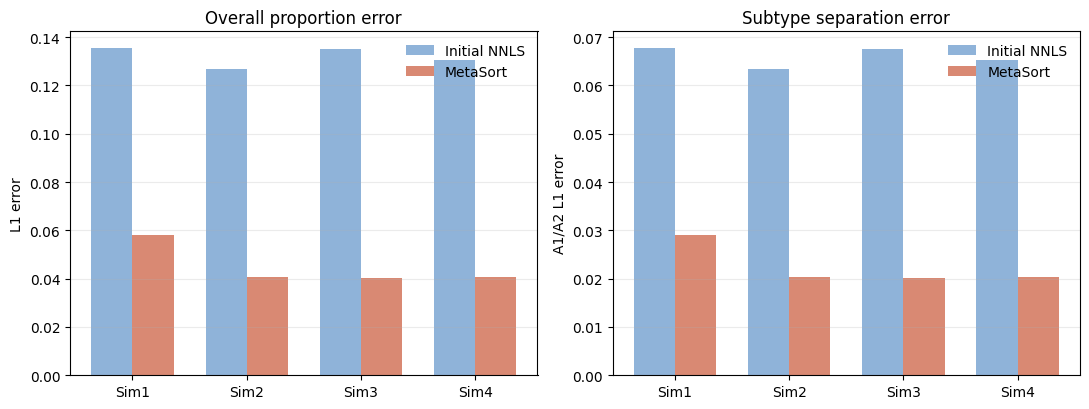

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(len(summary_df))
width = 0.36

axes[0].bar(x - width / 2, summary_df["Initial_L1"], width, label="Initial NNLS", color="#8fb3d9")
axes[0].bar(x + width / 2, summary_df["MetaSort_L1"], width, label="MetaSort", color="#d98973")
axes[0].set_xticks(x, summary_df["Simulation"])
axes[0].set_ylabel("L1 error")
axes[0].set_title("Overall proportion error")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(frameon=False)

axes[1].bar(x - width / 2, summary_df["Initial_A1A2_L1"], width, label="Initial NNLS", color="#8fb3d9")
axes[1].bar(x + width / 2, summary_df["MetaSort_A1A2_L1"], width, label="MetaSort", color="#d98973")
axes[1].set_xticks(x, summary_df["Simulation"])
axes[1].set_ylabel("A1/A2 L1 error")
axes[1].set_title("Subtype separation error")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## Gene Block Weight Summary

The table and plots below aggregate the learned weights by synthetic gene block. `TotalWeight = BaseWeight * MetaWeight` is the final weight used by weighted NNLS. For this case, the expected pattern is lower weight on the shared noisy A1/A2 block and higher relative weight on the stable A1/A2 marker blocks.

In [25]:
block_weight_summary = (
    weights_df
    .groupby("Block", sort=False)
    .agg(
        NGenes=("Gene", "nunique"),
        BaseMean=("BaseWeight", "mean"),
        BaseMedian=("BaseWeight", "median"),
        MetaMean=("MetaWeight", "mean"),
        MetaMedian=("MetaWeight", "median"),
        TotalMean=("TotalWeight", "mean"),
        TotalMedian=("TotalWeight", "median"),
        TotalP90=("TotalWeight", lambda x: np.quantile(x, 0.90)),
    )
    .reset_index()
)
block_weight_summary.round(4)

,Block,NGenes,BaseMean,BaseMedian,MetaMean,MetaMedian,TotalMean,TotalMedian,TotalP90
0,housekeeping,200,0.5491,0.5123,0.8647,0.8647,0.4748,0.4431,0.6058
1,shared_noisy_A1_A2,120,0.2821,0.2678,0.9452,0.9428,0.2676,0.2527,0.3697
2,A1_marker,30,1.2039,1.2159,1.3839,1.3844,1.6701,1.7009,1.9251
3,A2_marker,30,1.1936,1.2335,1.4015,1.4131,1.6779,1.7443,1.9574
4,B_marker,90,1.3128,1.2930,1.2174,1.2139,1.5990,1.5729,1.7316
5,C_marker,90,1.3504,1.3406,1.2215,1.2219,1.6503,1.6426,1.7658
6,weak_A1_marker,30,1.4363,1.4622,0.9216,0.9243,1.3243,1.3517,1.4219
7,weak_A2_marker,30,1.4363,1.4622,0.9248,0.9269,1.3290,1.3554,1.4296
8,background,180,1.4363,1.4622,0.8622,0.8625,1.2384,1.2611,1.3239


In [26]:
expected_blocks = ["shared_noisy_A1_A2", "A1_marker", "A2_marker", "weak_A1_marker", "weak_A2_marker"]
block_weight_summary.loc[block_weight_summary["Block"].isin(expected_blocks), [
    "Block", "NGenes", "BaseMedian", "MetaMedian", "TotalMedian", "TotalP90"
]].round(4)

,Block,NGenes,BaseMedian,MetaMedian,TotalMedian,TotalP90
1,shared_noisy_A1_A2,120,0.2678,0.9428,0.2527,0.3697
2,A1_marker,30,1.2159,1.3844,1.7009,1.9251
3,A2_marker,30,1.2335,1.4131,1.7443,1.9574
6,weak_A1_marker,30,1.4622,0.9243,1.3517,1.4219
7,weak_A2_marker,30,1.4622,0.9269,1.3554,1.4296


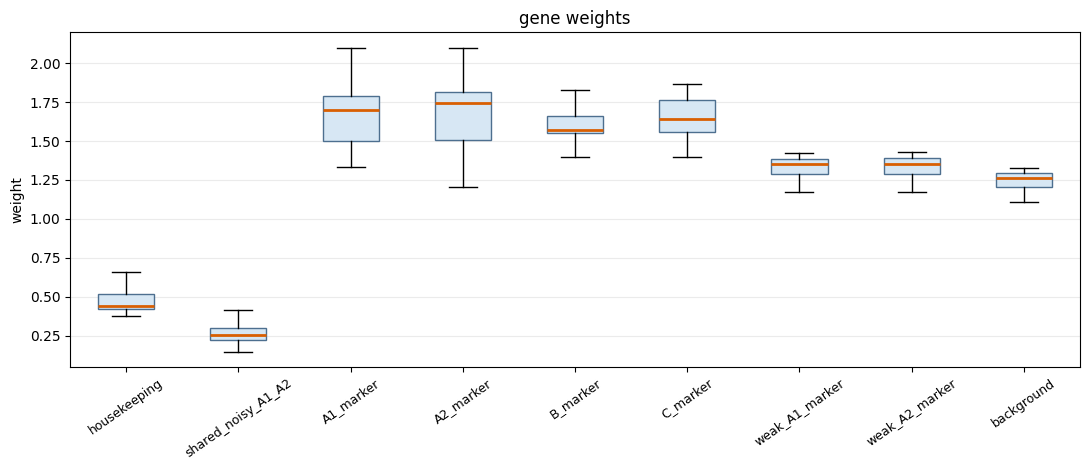

In [27]:
plot_order = list(BLOCKS.keys())
fig, ax = plt.subplots(figsize=(11, 4.8))
box_data = [weights_df.loc[weights_df["Block"] == block, "TotalWeight"].to_numpy() for block in plot_order]
box = ax.boxplot(box_data, tick_labels=plot_order, patch_artist=True, showfliers=False)
for patch in box["boxes"]:
    patch.set_facecolor("#d7e7f4")
    patch.set_edgecolor("#4d6f8f")
for median in box["medians"]:
    median.set_color("#d95f02")
    median.set_linewidth(2.0)
ax.set_ylabel("weight")
ax.set_title("gene weights")
ax.tick_params(axis="x", rotation=35, labelsize=9)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

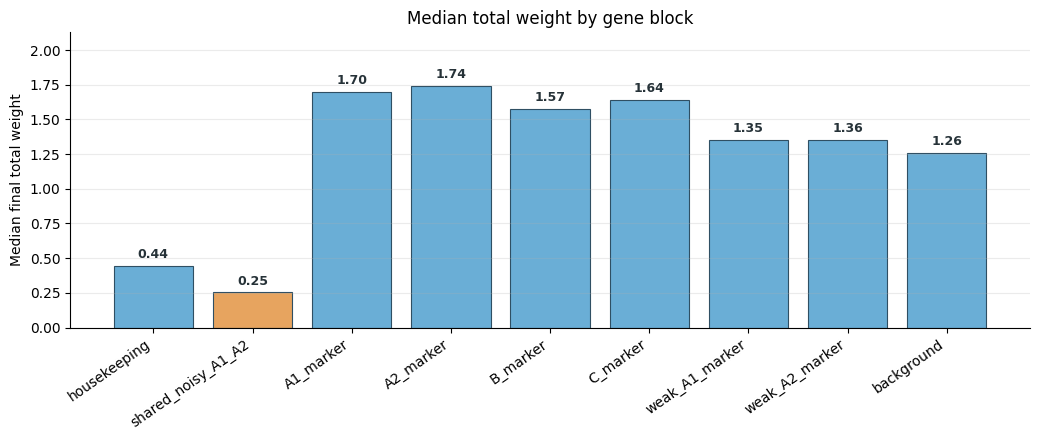

In [28]:
median_df = block_weight_summary.set_index("Block").loc[plot_order].reset_index()

fig, ax = plt.subplots(figsize=(10.5, 4.5))
bar_colors = ["#e7a45f" if block == "shared_noisy_A1_A2" else "#6aaed6" for block in median_df["Block"]]
bars = ax.bar(
    np.arange(len(median_df)),
    median_df["TotalMedian"],
    color=bar_colors,
    edgecolor="#2f4f63",
    linewidth=0.8,
)

for bar, value in zip(bars, median_df["TotalMedian"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.035,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#263238",
    )

ax.set_xticks(np.arange(len(median_df)), median_df["Block"], rotation=35, ha="right")
ax.set_ylabel("Median final total weight")
ax.set_title("Median total weight by gene block")
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(0, median_df["TotalMedian"].max() * 1.22)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

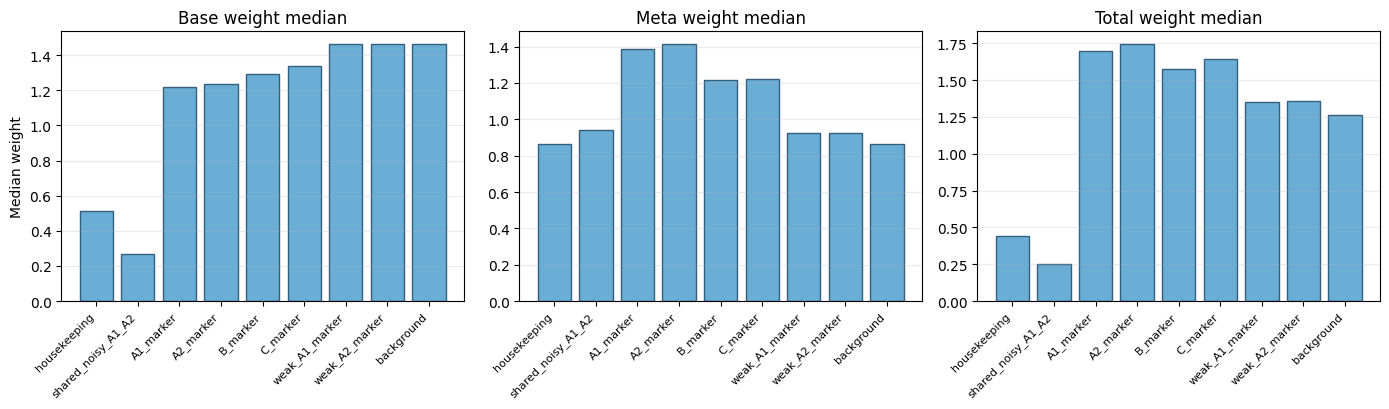

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
metrics = [("BaseWeight", "Base weight"), ("MetaWeight", "Meta weight"), ("TotalWeight", "Total weight")]
summary_for_plot = block_weight_summary.set_index("Block").loc[plot_order]
for ax, (column, title) in zip(axes, metrics):
    values = summary_for_plot[column.replace("Weight", "Median") if column != "TotalWeight" else "TotalMedian"]
    ax.bar(np.arange(len(plot_order)), values, color="#6aaed6", edgecolor="#365f7d")
    ax.set_title(title + " median")
    ax.set_xticks(np.arange(len(plot_order)), plot_order, rotation=45, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Median weight")
plt.tight_layout()
plt.show()

In [30]:
weights_out_path = REPO_ROOT / "synthetic_subtype_block_weight_summary.csv"
block_weight_summary.to_csv(weights_out_path, index=False)
print(f"Saved: {weights_out_path}")

Saved: /home/yunhao/WeightOptimizationDebug/metasort_jk/synthetic_subtype_block_weight_summary.csv


## Gene Block Structure

This schematic is included to make the synthetic design explicit. The A1/A2 shared noisy block is deliberately high-expression and large, while A1/A2 marker blocks are smaller but more subtype-specific.

In [31]:
block_rows = []
for block_name, (start, end) in BLOCKS.items():
    block_rows.append({
        "Block": block_name,
        "StartGeneIndex": start,
        "EndGeneIndexExclusive": end,
        "NGenes": end - start,
        "Mean_A1": signature[start:end, 0].mean(),
        "Mean_A2": signature[start:end, 1].mean(),
        "Mean_B": signature[start:end, 2].mean(),
        "Mean_C": signature[start:end, 3].mean(),
    })
block_df = pd.DataFrame(block_rows)
block_df.round(6)

,Block,StartGeneIndex,EndGeneIndexExclusive,NGenes,Mean_A1,Mean_A2,Mean_B,Mean_C
0,housekeeping,0,200,200,0.001867,0.001899,0.002391,0.002320
1,shared_noisy_A1_A2,200,320,120,0.003942,0.003868,0.000217,0.000232
2,A1_marker,320,350,30,0.002351,0.000141,0.000217,0.000232
3,A2_marker,350,380,30,0.000138,0.002391,0.000217,0.000232
4,B_marker,380,470,90,0.000138,0.000141,0.004565,0.000232
5,C_marker,470,560,90,0.000138,0.000141,0.000217,0.004640
6,weak_A1_marker,560,590,30,0.000830,0.000141,0.000217,0.000232
7,weak_A2_marker,590,620,30,0.000138,0.000844,0.000217,0.000232
8,background,620,800,180,0.000138,0.000141,0.000217,0.000232


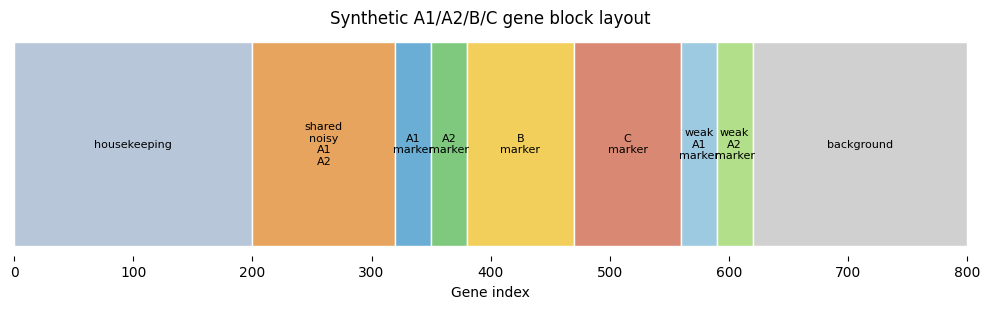

In [32]:
fig, ax = plt.subplots(figsize=(10, 3.2))
left = 0
colors = {
    "housekeeping": "#b8c6d9",
    "shared_noisy_A1_A2": "#e7a45f",
    "A1_marker": "#6aaed6",
    "A2_marker": "#7fc97f",
    "B_marker": "#f2cf5b",
    "C_marker": "#d98973",
    "weak_A1_marker": "#9ecae1",
    "weak_A2_marker": "#b2df8a",
    "background": "#d0d0d0",
}
for block_name, (start, end) in BLOCKS.items():
    block_width = end - start
    ax.barh([0], [block_width], left=[left], color=colors[block_name], edgecolor="white")
    if block_width >= 30:
        ax.text(left + block_width / 2, 0, block_name.replace("_", "\n"), ha="center", va="center", fontsize=8)
    left += block_width
ax.set_xlim(0, signature.shape[0])
ax.set_yticks([])
ax.set_xlabel("Gene index")
ax.set_title("Synthetic A1/A2/B/C gene block layout")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()